# Construcción de Señal

* Universidad de Chile

* Franco Mansilla Ibáñez (www.francomansilla.com)

# 1. Librerías

In [1]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt

# 2. Carga de Datos

* Datos historicos de la acción de ``Falabella``


In [2]:
start = '2020-01-01'
end = '2022-12-31'

df = yf.download('FALABELLA.SN', start= start, end = end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN,FALABELLA.SN
Date,,,,,,
2020-01-02 00:00:00+00:00,3206.914795,3350.000000,3379.000000,3241.000000,3350.000000,252306
2020-01-03 00:00:00+00:00,3223.271729,3350.000000,3378.899902,3211.000000,3350.000000,281213
2020-01-06 00:00:00+00:00,3261.758301,3390.000000,3394.000000,3299.899902,3390.000000,113081
2020-01-07 00:00:00+00:00,3319.488770,3450.000000,3495.000000,3380.000000,3450.000000,273437
2020-01-08 00:00:00+00:00,3325.165527,3455.899902,3520.000000,3365.100098,3455.899902,317642


In [3]:
df = df[['Adj Close']].dropna()
df

Price,Adj Close
Ticker,FALABELLA.SN
Date,
2020-01-02 00:00:00+00:00,3206.914795
2020-01-03 00:00:00+00:00,3223.271729
2020-01-06 00:00:00+00:00,3261.758301
2020-01-07 00:00:00+00:00,3319.488770
2020-01-08 00:00:00+00:00,3325.165527
...,...
2022-12-26 00:00:00+00:00,1655.000000
2022-12-27 00:00:00+00:00,1648.599976


# 3. Construcción Media Móvil (5 y 20 días)

In [4]:
# Media Movil Exponencial de 5 días (MME_5d)
df['MME_5d'] = df['Adj Close'].rolling(window = 5).mean()
#df['MME_5d'] = df['Adj Close'].ewm(span = 5, adjust = False). mean()

# Media Movil Exponencial de 5 días (MME_5d)
df['MME_20d'] = df['Adj Close'].rolling(window = 20).mean()
#df['MME_20d'] = df['Adj Close'].ewm(span = 20, adjust = False). mean()

df.head()

Price,Adj Close,MME_5d,MME_20d
Ticker,FALABELLA.SN,,
Date,,,
2020-01-02 00:00:00+00:00,3206.914795,NaN,NaN
2020-01-03 00:00:00+00:00,3223.271729,NaN,NaN
2020-01-06 00:00:00+00:00,3261.758301,NaN,NaN
2020-01-07 00:00:00+00:00,3319.488770,NaN,NaN
2020-01-08 00:00:00+00:00,3325.165527,3267.319824,NaN


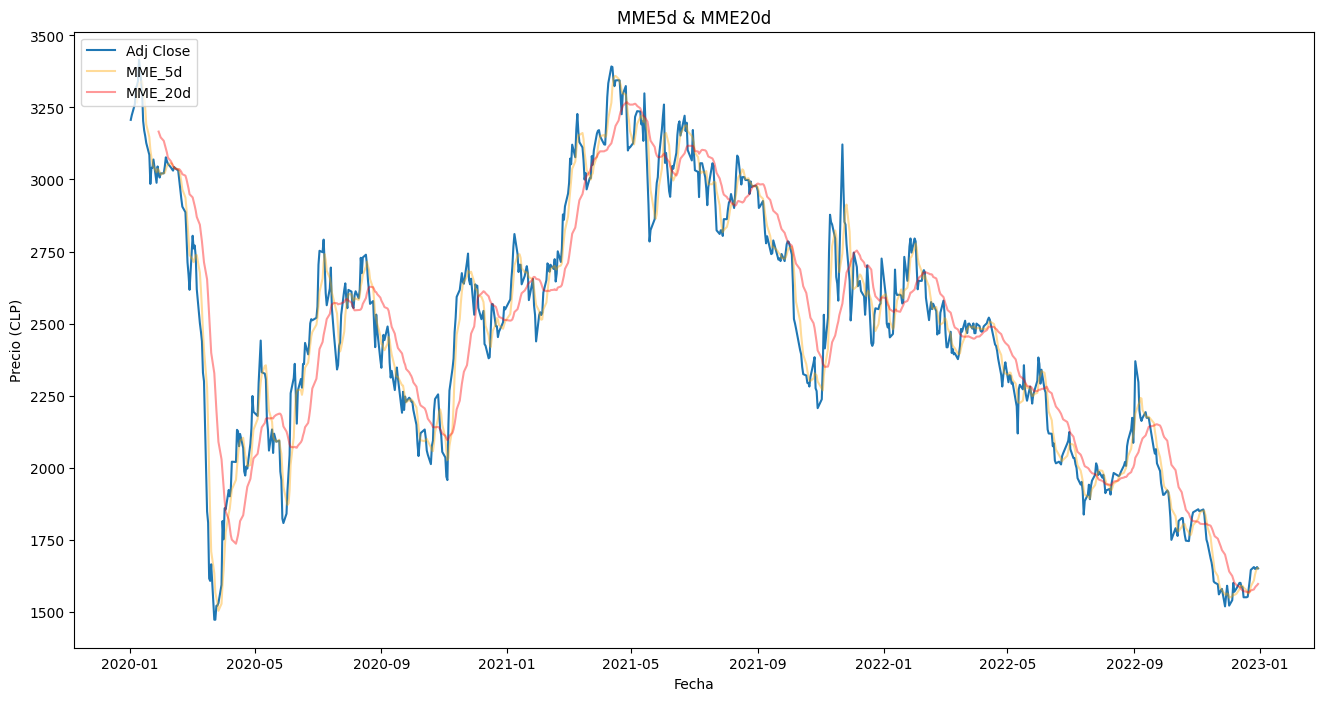

In [5]:
plt.figure(figsize = (16,8))
plt.title('MME5d & MME20d')
plt.plot(df['Adj Close'])
plt.plot(df['MME_5d'], color = 'orange', alpha = 0.4)
plt.plot(df['MME_20d'], color = 'red', alpha = 0.4)
plt.xlabel('Fecha')
plt.ylabel('Precio (CLP)')
plt.legend(['Adj Close', 'MME_5d', 'MME_20d'], loc = 'upper left')

# 4. Construcción de la Señal

In [6]:
# Número de datos
obs = len(df)

# Lista de señales: -1 (vender); 0 (mantener); 1 (comprar)
señales = [0]

# comienza en 1 dado que en el rezago no tiene dato anterior.
for i in range(1, obs):

  # Tenemos que recorrer el precio para cada día.
  corto_plazo = df['MME_5d'][i]
  largo_plazo = df['MME_20d'][i]

  # Señal de compra: el precio anterior de la media del corto plazo debe estar por debajo de la media de largo plazo
  p_corto_plazo = df['MME_5d'][i-1] # día anterior
  p_largo_plazo = df['MME_20d'][i-1]


  # Señal de compra
  if p_corto_plazo < p_largo_plazo and corto_plazo >= largo_plazo:
    señales.append(1)

  # Señal de venta
  elif p_corto_plazo > p_largo_plazo and corto_plazo <= largo_plazo:
    señales.append(-1)

  # Señal de mantener
  else:
    señales.append(0)

df['señales'] = señales

df.head()

<ipython-input-6-b530ee78ceb5>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  corto_plazo = df['MME_5d'][i]
<ipython-input-6-b530ee78ceb5>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  largo_plazo = df['MME_20d'][i]
<ipython-input-6-b530ee78ceb5>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_corto_plazo = df['MME_5d'][i-1] # día anterior
<ipython-input-6-b530ee78ceb5>:16: FutureWarning: Series.__getitem__ treating keys 

Price,Adj Close,MME_5d,MME_20d,señales
Ticker,FALABELLA.SN,,,
Date,,,,
2020-01-02 00:00:00+00:00,3206.914795,NaN,NaN,0
2020-01-03 00:00:00+00:00,3223.271729,NaN,NaN,0
2020-01-06 00:00:00+00:00,3261.758301,NaN,NaN,0
2020-01-07 00:00:00+00:00,3319.488770,NaN,NaN,0
2020-01-08 00:00:00+00:00,3325.165527,3267.319824,NaN,0


In [7]:
# Crear columnas 'compra' y 'venta' con np.where
df['compra'] = np.where(df['señales'] == 1, df['Adj Close'].values.ravel(), np.nan)
df['venta'] = np.where(df['señales'] == -1, df['Adj Close'].values.ravel(), np.nan)

df.head()

Price,Adj Close,MME_5d,MME_20d,señales,compra,venta
Ticker,FALABELLA.SN,,,,,
Date,,,,,,
2020-01-02 00:00:00+00:00,3206.914795,NaN,NaN,0,NaN,NaN
2020-01-03 00:00:00+00:00,3223.271729,NaN,NaN,0,NaN,NaN
2020-01-06 00:00:00+00:00,3261.758301,NaN,NaN,0,NaN,NaN
2020-01-07 00:00:00+00:00,3319.488770,NaN,NaN,0,NaN,NaN
2020-01-08 00:00:00+00:00,3325.165527,3267.319824,NaN,0,NaN,NaN


Text(0, 0.5, 'Precios (CLP)')

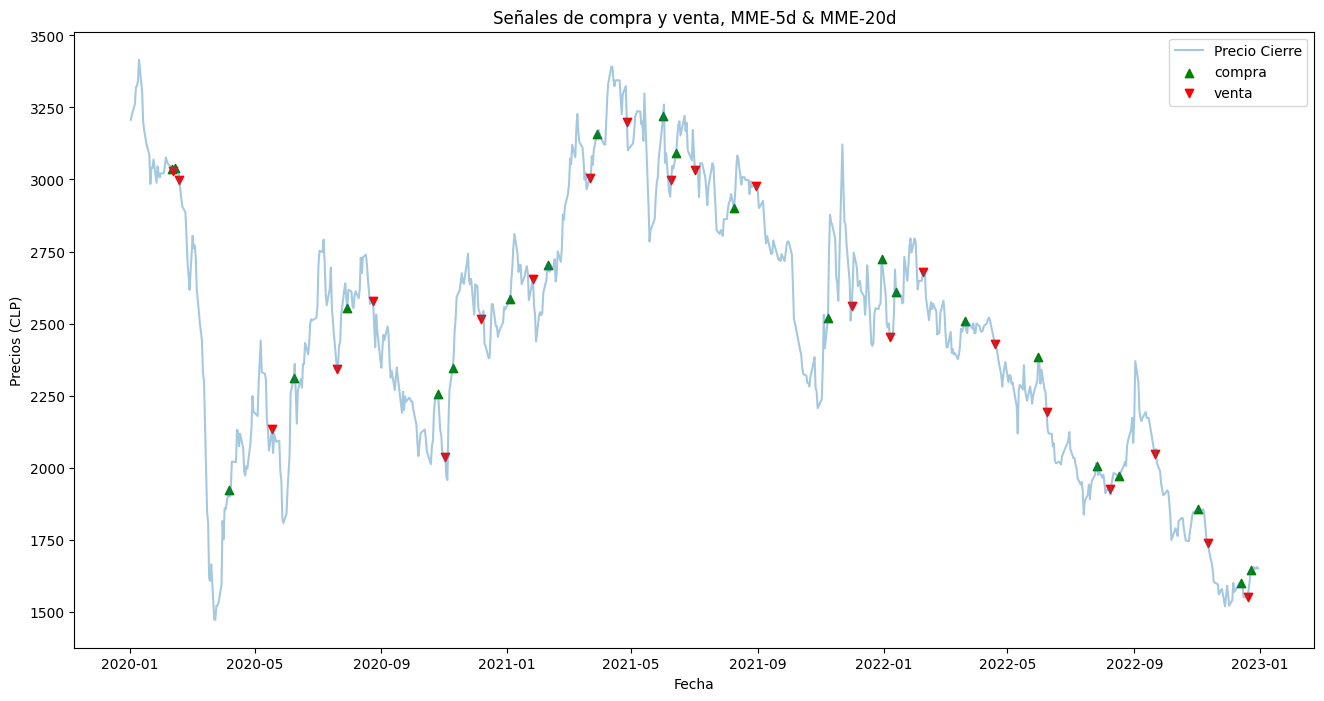

In [8]:
plt.figure(figsize = (16,8))
plt.plot(df['Adj Close'], alpha = 0.4, label = 'Precio Cierre')
plt.scatter(df.index, df['compra'], color = 'green', marker = '^', label = 'compra')
plt.scatter(df.index, df['venta'], color = 'red', marker = 'v', label = 'venta')

plt.title('Señales de compra y venta, MME-5d & MME-20d')
plt.xlabel('Fecha')
plt.legend(loc = 'upper right')
plt.ylabel('Precios (CLP)')

# 5. Backtesting

In [9]:
obs = len(df)

# Dinero inicial
capital = [100]

TP = 0.03
SL = 0.01

# Parte en 0, dado que no hay ninguna posición de compra o venta
posicion = 0

precio = 0

# Capital de 100 en día 0 (por eso parte en 100)
for i in range(1, obs):
    capital.append(capital[i-1])

    adj_close = df['Adj Close'].iloc[i]  # Asegurarse de que es un valor escalar

    if isinstance(adj_close, pd.Series):  # Verificar si aún es una Serie
        adj_close = adj_close.iloc[0]     # Convertir a escalar si es necesario

    if posicion == 1:
        if adj_close >= precio * (1 + TP):
            posicion = 0
            capital[i] = capital[i-1] * (1 + TP)
        elif adj_close <= precio * (1 - SL):
            posicion = 0
            capital[i] = capital[i-1] * (1 - SL)

    elif posicion == -1:
        if adj_close <= precio * (1 - TP):
            posicion = 0
            capital[i] = capital[i-1] * (1 + TP)
        elif adj_close >= precio * (1 + SL):
            posicion = 0
            capital[i] = capital[i-1] * (1 - SL)

    else:
        if df['señales'].iloc[i] != 0:
            posicion = df['señales'].iloc[i]
            precio = adj_close  # Asegurarse de que es un valor escalar

df['capital'] = capital
df.head()

Price,Adj Close,MME_5d,MME_20d,señales,compra,venta,capital
Ticker,FALABELLA.SN,,,,,,
Date,,,,,,,
2020-01-02 00:00:00+00:00,3206.914795,NaN,NaN,0,NaN,NaN,100.0
2020-01-03 00:00:00+00:00,3223.271729,NaN,NaN,0,NaN,NaN,100.0
2020-01-06 00:00:00+00:00,3261.758301,NaN,NaN,0,NaN,NaN,100.0
2020-01-07 00:00:00+00:00,3319.488770,NaN,NaN,0,NaN,NaN,100.0
2020-01-08 00:00:00+00:00,3325.165527,3267.319824,NaN,0,NaN,NaN,100.0


Text(0, 0.5, 'CLP $')

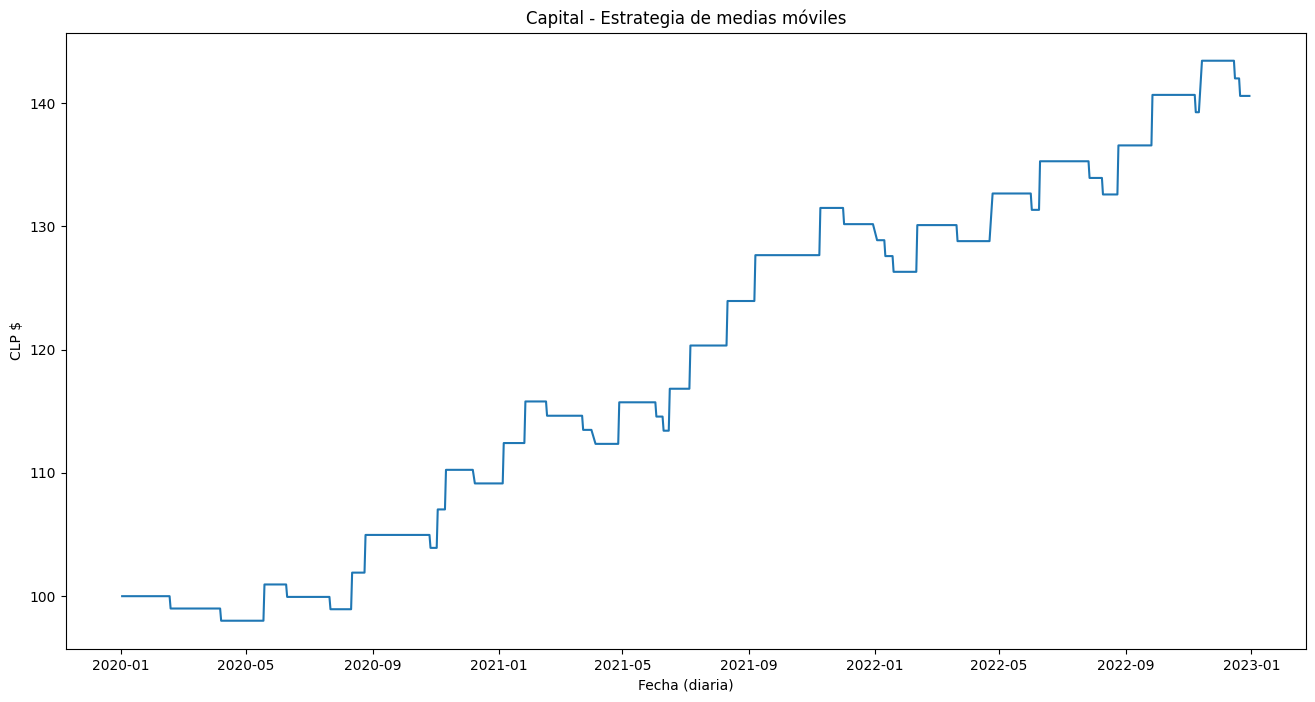

In [10]:
plt.figure(figsize = (16,8))
plt.plot(df['capital'])
plt.title('Capital - Estrategia de medias móviles')
plt.xlabel('Fecha (diaria)')
plt.ylabel('CLP $')

# 6. Ratio de Sharpe

In [11]:
retorno = np.log(df['capital']).diff().mean()
retorno_anual = ((1+retorno)**252)-1
retorno_anual

0.12118408614961473

In [12]:
volatilidad = np.log(df['capital']).diff().std()
volatilidad_anual = volatilidad*np.sqrt(252)
volatilidad_anual

0.07925236284878483

In [13]:
rf = 0.05
sharpe = (retorno_anual - rf)/volatilidad_anual
sharpe

0.8981951274492025